# Run a simulation of EndAI.

Clone the repo:

In [6]:
!git clone https://github.com/PrimozRavbar/EndAI-evolving-neural-dynamics-in-agent-interaction.git
%cd EndAI-evolving-neural-dynamics-in-agent-interaction

Cloning into 'EndAI-evolving-neural-dynamics-in-agent-interaction'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 64 (delta 22), reused 39 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 2.63 MiB | 39.62 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/EndAI-evolving-neural-dynamics-in-agent-interaction/EndAI-evolving-neural-dynamics-in-agent-interaction


Load three example genomes:

In [8]:
import time
import numpy as np

from endai.evolution import Evolution
from endai.simulation import run_episode

pool_folder_name = "genomes/genomes_examples/"

evol = Evolution()

popul = evol.select_popul_from_pool_1(
    3,
    pool_folder_name
)

solution = popul[0, :]

print("Population shape:", popul.shape)
print("Solution shape:", solution.shape)

Population shape: (3, 191777)
Solution shape: (191777,)


Run one episode and record the video and data:

In [11]:
TIME_TOT = 1000

list_elim_hidden = []
list_elim_hidden_out = []

ts = time.time()

fitness_vect, raw_im, list_of_agents, data_rec_dic, frames = run_episode(
    solution,
    popul,
    TIME_TOT,
    list_elim_hidden,
    list_elim_hidden_out,
    display_movie=True,
    record_data=True
)

te = time.time()

print("Time:", te - ts)
print("Fitness:", np.round(fitness_vect))

ag = list_of_agents[0]

Time: 15.226380348205566
Fitness: [[436. 214.  67.]]


Play the video (if created):

In [12]:

from IPython.display import Video, display

display(Video("simulation.mp4", embed=True))

# Analysis:

Raw time-series of hidden and output activities:

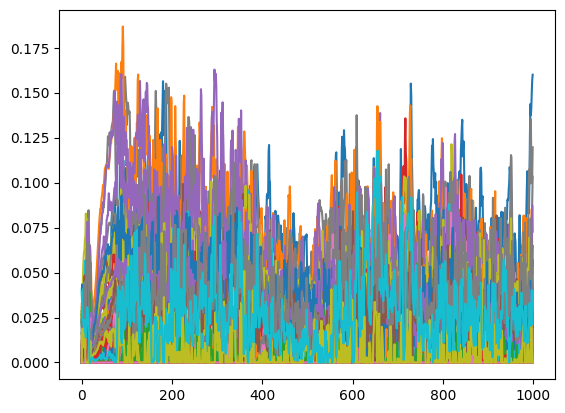

In [18]:

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cmap

from sklearn.decomposition import PCA
import umap

out = data_rec_dic["output_rec"]
hid = data_rec_dic["hidden_rec"]

pos_rec = data_rec_dic["pos_rec"]

Wi = ag.model.W_sens_hidden.detach().cpu().numpy()
Wo = ag.model.W_hidden_out.detach().cpu().numpy()
Wh = ag.model.W_hidden.detach().cpu().numpy()

lim1=0
lim2=1000

plt.plot(np.transpose(hid[:,lim1:lim2]))

<Figure size 700x560 with 0 Axes>

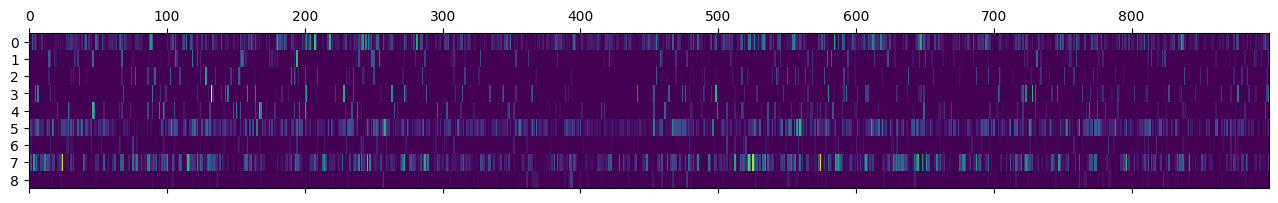

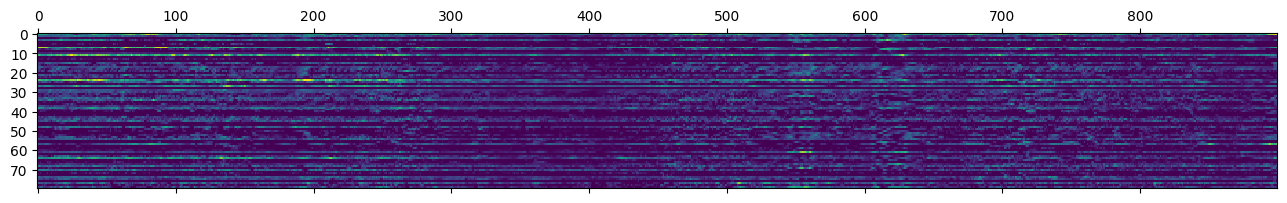

In [19]:
fig = plt.figure(figsize=(5, 4), dpi=140)
font = {'family' : 'sans-serif',
        'weight' : 'light',
        'size'   : 10}
matplotlib.rc('font', **font)

lim1=100
lim2=1000

plt.matshow(out[:,lim1:lim2], aspect = 'auto')

plt.matshow(hid[:,lim1:lim2], aspect = 'auto')

Run UMAP over the neural activities:

In [20]:
# get UMAPs

reducer = umap.UMAP(
    #n_neighbors=350,
    n_neighbors=550,
    min_dist=0.7,
    n_components=2,
)

lim_1 = 0
lim_2 = 1000

#X = np.transpose(out[:,0:500])
Xh = np.transpose(hid[:,lim_1:lim_2])
Xo = np.transpose(out[:,lim_1:lim_2])

umap_emb_hid  = reducer.fit_transform(Xh)
umap_emb_out  = reducer.fit_transform(Xo)

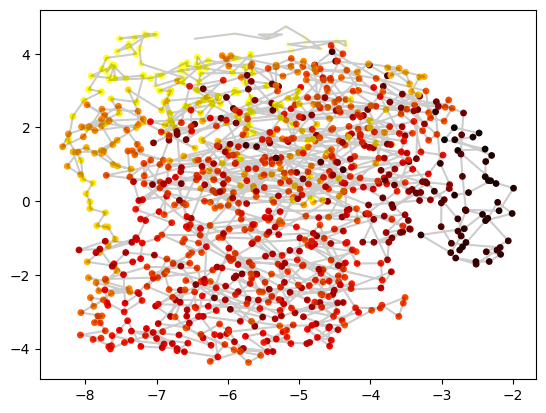

In [21]:
ind=0
color = pos_rec[ind,:]

color = (color - np.min(color)) / (np.max(color) - np.min(color))

plt.plot(umap_emb_hid[:,0],umap_emb_hid[:,1],'k',alpha=0.2)

plt.scatter(umap_emb_hid[:,0], umap_emb_hid[:,1], s=15,marker='o',
           c= color, cmap='hot')

PCA of neural activity:

In [23]:
# PCA of neural activity

pca = PCA(n_components=80)
projected_A = pca.fit_transform(Xh)  # Transpose to get time points as samples (1000x3)
projected_A = projected_A.T

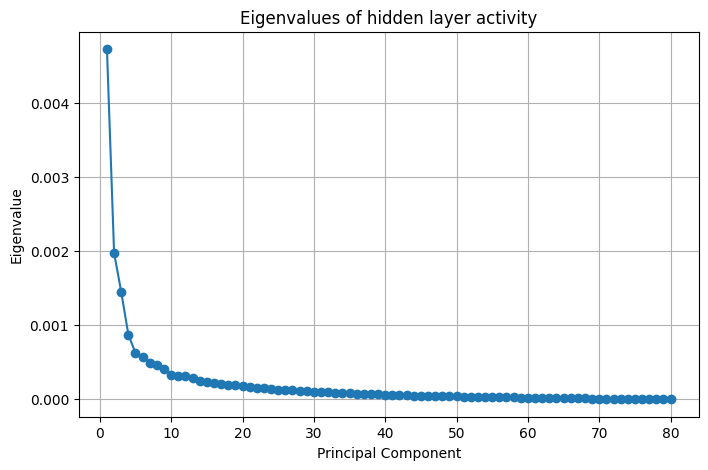

In [25]:
# Get eigenvalues (explained variance)
eigenvalues = pca.explained_variance_

# Plot eigenvalues (scree plot)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-')
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of hidden layer activity")
plt.grid(True)
plt.show()

Trajectories:

Text(0.5, 0.92, 'Neural Trajectory in PCA Space')

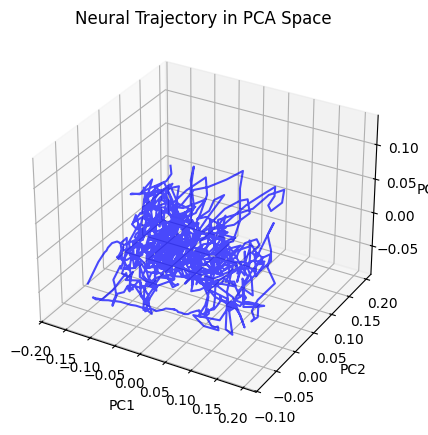

In [26]:
projected_A = projected_A.T
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection='3d')
ax.plot(projected_A[:, 0], projected_A[:, 1], projected_A[:, 2], color='b', alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Neural Trajectory in PCA Space")